# SAR Image Colorization — Upgraded Attention GAN

**Generator:** U-Net with a self-attention block at the 16x16 bottleneck + attention gates on every skip connection (Attention U-Net style)

**Discriminator:** Multi-scale PatchGAN (3 scales, Pix2PixHD style) with feature-matching loss for stability

**Loss:** LSGAN adversarial + feature matching + L1 + VGG perceptual + SSIM

Dataset: [Paired SAR-Optical Dataset (16K Images)](https://www.kaggle.com/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images) — each PNG has the SAR image on the left half and the paired optical image on the right half.

Run top to bottom on a Kaggle GPU notebook (P100/T4). Training and testing are both in this notebook — scroll to the bottom for the evaluation section once training finishes.

## 1. Imports

In [1]:
import os
import random
import math
import json
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils as vutils
import torchvision
from PIL import Image
import matplotlib.pyplot as plt

## 2. Config

Edit `DATA_DIR` if your dataset path differs. Everything else is tuned to run comfortably on a Kaggle P100/T4 with AMP enabled.

- `BATCH_SIZE=8` fits most Kaggle GPUs with mixed precision; drop to 4 if you hit CUDA OOM (VGG + 3 discriminators are memory-hungry).
- `SPLIT_SEED` must stay the same between training and testing — it's what guarantees the test set is genuinely unseen data.
- `RESUME=True` means re-running this notebook picks up from the last checkpoint automatically, which matters since Kaggle sessions cap around 9–12 hours.

In [2]:
CFG = dict(
    DATA_DIR="/kaggle/input/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images/Paired_SAR_Optical_images",
    OUTPUT_DIR="/kaggle/working",
    IMG_SIZE=256,
    BATCH_SIZE=8,
    NUM_WORKERS=2,
    EPOCHS=60,
    LR=2e-4,
    BETA1=0.5,
    BETA2=0.999,
    VAL_RATIO=0.02,
    SPLIT_SEED=42,
    SAVE_EVERY=5,
    LAMBDA_GAN=1.0,
    LAMBDA_FM=10.0,
    LAMBDA_L1=50.0,
    LAMBDA_VGG=10.0,
    LAMBDA_SSIM=10.0,
    NGF=64,
    NDF=64,
    NUM_SCALES=3,
    RESUME=True,
)

CKPT_DIR = os.path.join(CFG["OUTPUT_DIR"], "checkpoints")
SAMPLE_DIR = os.path.join(CFG["OUTPUT_DIR"], "samples")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

torch.manual_seed(CFG["SPLIT_SEED"])
random.seed(CFG["SPLIT_SEED"])
np.random.seed(CFG["SPLIT_SEED"])

Device: cuda


## 3. Dataset

Same left/right crop logic as your original demo, extended with a **deterministic** train/val split (fixed seed + shuffle) so the held-out images stay identical across every run — this is what makes the test metrics later trustworthy.

In [3]:
class SAROpticalDataset(Dataset):
    def __init__(self, data_dir, img_size=256, split="train", val_ratio=0.02, seed=42):
        self.data_dir = data_dir
        self.img_size = img_size

        all_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".png")])
        rng = random.Random(seed)
        rng.shuffle(all_files)

        n_val = int(len(all_files) * val_ratio)
        if split == "train":
            self.files = all_files[n_val:]
        else:
            self.files = all_files[:n_val]

        print(f"[{split}] {len(self.files)} images")

        self.resize = transforms.Resize((img_size, img_size),
                                         interpolation=transforms.InterpolationMode.BICUBIC)
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize([0.5] * 3, [0.5] * 3)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.files[idx])
        img = Image.open(img_path).convert("RGB")

        w, h = img.size
        half_w = w // 2
        sar_img = img.crop((0, 0, half_w, h))
        opt_img = img.crop((half_w, 0, w, h))

        sar_img = self.resize(sar_img)
        opt_img = self.resize(opt_img)

        sar_tensor = self.normalize(self.to_tensor(sar_img)).mean(dim=0, keepdim=True)
        opt_tensor = self.normalize(self.to_tensor(opt_img))

        return sar_tensor, opt_tensor

Quick sanity check, same as your original demo:

In [4]:
_check_ds = SAROpticalDataset(CFG["DATA_DIR"], CFG["IMG_SIZE"], split="train",
                               val_ratio=CFG["VAL_RATIO"], seed=CFG["SPLIT_SEED"])
_check_loader = DataLoader(_check_ds, batch_size=4, shuffle=True, num_workers=2)
sar_batch, opt_batch = next(iter(_check_loader))
print(f"SAR shape:     {sar_batch.shape}")
print(f"Optical shape: {opt_batch.shape}")
print("Dataset ready!")
del _check_ds, _check_loader, sar_batch, opt_batch

[train] 15680 images
SAR shape:     torch.Size([4, 1, 256, 256])
Optical shape: torch.Size([4, 3, 256, 256])
Dataset ready!


## 4. Attention building blocks

- **SelfAttention** — SAGAN-style self-attention, placed at the 16x16 bottleneck layer to capture long-range spatial dependencies (terrain patterns, large structures) that pure convolutions miss.
- **AttentionGate** — Oktay et al.'s Attention U-Net gate, applied to every skip connection so the decoder learns to weight *which* encoder features actually matter instead of blindly concatenating everything.

**Note on normalization choice:** this uses `InstanceNorm2d`, not `BatchNorm2d`. BatchNorm tracks running statistics that are only used at `.eval()` time — if any single early training step produces extreme or NaN activations, that gets baked into the running average permanently, but stays invisible during training (which uses live batch stats) and only surfaces as NaN output once you switch to `.eval()` for testing. InstanceNorm has no running statistics to corrupt, so it can't fail this way, and it matches the norm used everywhere else in the generator.

In [5]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, max(in_dim // 8, 1), 1)
        self.key = nn.Conv2d(in_dim, max(in_dim // 8, 1), 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        B, C, H, W = x.size()
        q = self.query(x).view(B, -1, H * W).permute(0, 2, 1)
        k = self.key(x).view(B, -1, H * W)
        attn = self.softmax(torch.bmm(q, k))
        v = self.value(x).view(B, -1, H * W)
        out = torch.bmm(v, attn.permute(0, 2, 1)).view(B, C, H, W)
        return self.gamma * out + x


class AttentionGate(nn.Module):
    def __init__(self, f_g, f_l, f_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(f_g, f_int, 1, bias=True), nn.InstanceNorm2d(f_int))
        self.W_x = nn.Sequential(nn.Conv2d(f_l, f_int, 1, bias=True), nn.InstanceNorm2d(f_int))
        self.psi = nn.Sequential(nn.Conv2d(f_int, 1, 1, bias=True), nn.InstanceNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi

## 5. Generator — Attention U-Net

256x256 grayscale SAR in, 256x256 RGB optical out. Encoder/decoder mirrors the classic pix2pix U-Net, with the self-attention block inserted at the 16x16 layer and attention gates wired into all four higher-resolution skip connections.

In [6]:
def down_block(in_c, out_c, normalize=True, dropout=0.0):
    layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=not normalize)]
    if normalize:
        layers.append(nn.InstanceNorm2d(out_c))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    if dropout:
        layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)


def up_block(in_c, out_c, dropout=0.0):
    layers = [nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
              nn.InstanceNorm2d(out_c), nn.ReLU(inplace=True)]
    if dropout:
        layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)


class AttentionUNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, ngf=64):
        super().__init__()
        self.down1 = down_block(in_channels, ngf, normalize=False)   # 256 -> 128
        self.down2 = down_block(ngf, ngf * 2)                         # 128 -> 64
        self.down3 = down_block(ngf * 2, ngf * 4)                     # 64  -> 32
        self.down4 = down_block(ngf * 4, ngf * 8)                     # 32  -> 16
        self.self_attn = SelfAttention(ngf * 8)                       # at 16x16
        self.down5 = down_block(ngf * 8, ngf * 8)                     # 16  -> 8
        self.down6 = down_block(ngf * 8, ngf * 8)                     # 8   -> 4
        self.down7 = down_block(ngf * 8, ngf * 8, normalize=False)    # 4   -> 2

        self.up1 = up_block(ngf * 8, ngf * 8, dropout=0.5)            # 2 -> 4
        self.up2 = up_block(ngf * 16, ngf * 8, dropout=0.5)           # 4 -> 8
        self.up3 = up_block(ngf * 16, ngf * 8, dropout=0.5)           # 8 -> 16
        self.ag3 = AttentionGate(ngf * 8, ngf * 8, ngf * 4)
        self.up4 = up_block(ngf * 16, ngf * 4)                        # 16 -> 32
        self.ag4 = AttentionGate(ngf * 4, ngf * 4, ngf * 2)
        self.up5 = up_block(ngf * 8, ngf * 2)                         # 32 -> 64
        self.ag5 = AttentionGate(ngf * 2, ngf * 2, ngf)
        self.up6 = up_block(ngf * 4, ngf)                             # 64 -> 128
        self.ag6 = AttentionGate(ngf, ngf, ngf // 2)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, out_channels, 4, 2, 1),       # 128 -> 256
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d4 = self.self_attn(d4)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)

        u1 = self.up1(d7)
        u1 = torch.cat([u1, d6], dim=1)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d5], dim=1)
        u3 = self.up3(u2)
        u3 = torch.cat([u3, self.ag3(g=u3, x=d4)], dim=1)
        u4 = self.up4(u3)
        u4 = torch.cat([u4, self.ag4(g=u4, x=d3)], dim=1)
        u5 = self.up5(u4)
        u5 = torch.cat([u5, self.ag5(g=u5, x=d2)], dim=1)
        u6 = self.up6(u5)
        u6 = torch.cat([u6, self.ag6(g=u6, x=d1)], dim=1)
        return self.final(u6)

## 6. Discriminator — Multi-scale PatchGAN

Three PatchGAN discriminators looking at the image at full resolution, half, and quarter resolution (Pix2PixHD style). Each returns its intermediate feature maps too, since we use them below for the feature-matching loss — this is what keeps multi-scale GAN training from diverging.

In [7]:
class NLayerDiscriminator(nn.Module):
    def __init__(self, in_channels=4, ndf=64, n_layers=3):
        super().__init__()
        blocks = [[nn.Conv2d(in_channels, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True)]]
        nf = ndf
        for _ in range(1, n_layers):
            nf_prev, nf = nf, min(nf * 2, 512)
            blocks.append([nn.Conv2d(nf_prev, nf, 4, 2, 1), nn.InstanceNorm2d(nf), nn.LeakyReLU(0.2, True)])
        nf_prev, nf = nf, min(nf * 2, 512)
        blocks.append([nn.Conv2d(nf_prev, nf, 4, 1, 1), nn.InstanceNorm2d(nf), nn.LeakyReLU(0.2, True)])
        blocks.append([nn.Conv2d(nf, 1, 4, 1, 1)])
        self.blocks = nn.ModuleList([nn.Sequential(*b) for b in blocks])

    def forward(self, x):
        feats = [x]
        for block in self.blocks:
            feats.append(block(feats[-1]))
        return feats[1:]  # intermediate feats + final patch map (last element)


class MultiscaleDiscriminator(nn.Module):
    def __init__(self, in_channels=4, ndf=64, n_layers=3, num_scales=3):
        super().__init__()
        self.discriminators = nn.ModuleList(
            [NLayerDiscriminator(in_channels, ndf, n_layers) for _ in range(num_scales)]
        )
        self.downsample = nn.AvgPool2d(3, stride=2, padding=1, count_include_pad=False)

    def forward(self, x):
        results = []
        inp = x
        for i, D in enumerate(self.discriminators):
            results.append(D(inp))
            if i != len(self.discriminators) - 1:
                inp = self.downsample(inp)
        return results

## 7. Losses

- `gan_loss` — LSGAN (least-squares) adversarial loss, more stable than vanilla BCE.
- `feature_matching_loss` — L1 distance between real/fake intermediate discriminator features, the key stabilizer for multi-scale discriminators.
- `VGGPerceptualLoss` — VGG19 feature-space L1 loss. If your Kaggle session has internet disabled and the pretrained weights can't download, it disables itself automatically instead of crashing.
- `ssim` / `ssim_loss` — differentiable structural similarity, implemented from scratch (no extra pip installs needed).

In [8]:
def gan_loss(pred, target_is_real):
    target = torch.ones_like(pred) if target_is_real else torch.zeros_like(pred)
    return F.mse_loss(pred, target)


def feature_matching_loss(real_feats_list, fake_feats_list):
    loss = 0.0
    for real_feats, fake_feats in zip(real_feats_list, fake_feats_list):
        for rf, ff in zip(real_feats[:-1], fake_feats[:-1]):
            loss = loss + F.l1_loss(ff, rf.detach())
    return loss / len(real_feats_list)


class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        try:
            vgg = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT).features
            self.available = True
        except Exception as e:
            print("WARNING: could not download VGG19 weights (no internet on this Kaggle session?). "
                  "Perceptual loss will be disabled automatically.", e)
            self.available = False
            return

        layer_ids = [2, 7, 12, 21, 30]
        self.slices = nn.ModuleList()
        prev = 0
        for idx in layer_ids:
            self.slices.append(nn.Sequential(*[vgg[j] for j in range(prev, idx)]))
            prev = idx
        for p in self.parameters():
            p.requires_grad = False
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
        self.weights = [1 / 2.6, 1 / 4.8, 1 / 3.7, 1 / 5.6, 10 / 1.5]

    def forward(self, x, y):
        if not self.available:
            return torch.tensor(0.0, device=x.device)
        x, y = (x + 1) / 2, (y + 1) / 2
        x, y = (x - self.mean) / self.std, (y - self.mean) / self.std
        loss = 0.0
        fx, fy = x, y
        for i, s in enumerate(self.slices):
            fx, fy = s(fx), s(fy)
            loss = loss + self.weights[i] * F.l1_loss(fx, fy.detach())
        return loss


def gaussian_window(window_size, sigma, channel):
    coords = torch.arange(window_size).float() - window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = (g / g.sum()).unsqueeze(1)
    window_2d = g.mm(g.t()).unsqueeze(0).unsqueeze(0)
    return window_2d.expand(channel, 1, window_size, window_size).contiguous()


def ssim(img1, img2, window_size=11):
    channel = img1.size(1)
    window = gaussian_window(window_size, 1.5, channel).to(img1.device).type_as(img1)
    pad = window_size // 2
    mu1 = F.conv2d(img1, window, padding=pad, groups=channel)
    mu2 = F.conv2d(img2, window, padding=pad, groups=channel)
    mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2
    sigma1_sq = F.conv2d(img1 * img1, window, padding=pad, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=pad, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=pad, groups=channel) - mu1_mu2
    C1, C2 = 0.01 ** 2, 0.03 ** 2
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()


def ssim_loss(img1, img2):
    img1, img2 = (img1 + 1) / 2, (img2 + 1) / 2
    return 1 - ssim(img1, img2)

## 8. Dataloaders

`VAL_RATIO=0.02` of the 16K images (~320) is held out for both progress-monitoring during training and the final test metrics. This split is deterministic (`SPLIT_SEED`), so it stays identical every time you re-run the notebook.

In [9]:
train_ds = SAROpticalDataset(CFG["DATA_DIR"], CFG["IMG_SIZE"], split="train",
                              val_ratio=CFG["VAL_RATIO"], seed=CFG["SPLIT_SEED"])
val_ds = SAROpticalDataset(CFG["DATA_DIR"], CFG["IMG_SIZE"], split="val",
                            val_ratio=CFG["VAL_RATIO"], seed=CFG["SPLIT_SEED"])

train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,
                           num_workers=CFG["NUM_WORKERS"], pin_memory=True, drop_last=True)

fixed_sar, fixed_opt = next(iter(DataLoader(val_ds, batch_size=8, shuffle=False)))
fixed_sar, fixed_opt = fixed_sar.to(DEVICE), fixed_opt.to(DEVICE)

[train] 15680 images
[val] 319 images


## 9. Models, optimizers, schedulers

In [10]:
G = AttentionUNetGenerator(in_channels=1, out_channels=3, ngf=CFG["NGF"]).to(DEVICE)
D = MultiscaleDiscriminator(in_channels=4, ndf=CFG["NDF"], num_scales=CFG["NUM_SCALES"]).to(DEVICE)
vgg_loss_fn = VGGPerceptualLoss().to(DEVICE)

opt_G = torch.optim.Adam(G.parameters(), lr=CFG["LR"], betas=(CFG["BETA1"], CFG["BETA2"]))
opt_D = torch.optim.Adam(D.parameters(), lr=CFG["LR"], betas=(CFG["BETA1"], CFG["BETA2"]))


def lr_lambda(epoch):
    decay_start = CFG["EPOCHS"] // 2
    if epoch < decay_start:
        return 1.0
    return max(0.0, 1.0 - (epoch - decay_start) / float(CFG["EPOCHS"] - decay_start + 1))


sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
sched_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_lambda)

scaler_G = torch.cuda.amp.GradScaler()
scaler_D = torch.cuda.amp.GradScaler()

history = {"G": [], "D": [], "L1": [], "SSIM": []}
start_epoch = 0

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 186MB/s]
/tmp/ipykernel_23/1380027230.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = torch.cuda.amp.GradScaler()
/tmp/ipykernel_23/1380027230.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = torch.cuda.amp.GradScaler()


## 10. Resume + helper functions

Re-running the notebook automatically picks up from `checkpoints/last.pt` if it exists — useful since Kaggle sessions have a time limit.

In [11]:
last_ckpt_path = os.path.join(CKPT_DIR, "last.pt")
if CFG["RESUME"] and os.path.exists(last_ckpt_path):
    ckpt = torch.load(last_ckpt_path, map_location=DEVICE)
    G.load_state_dict(ckpt["G"])
    D.load_state_dict(ckpt["D"])
    opt_G.load_state_dict(ckpt["opt_G"])
    opt_D.load_state_dict(ckpt["opt_D"])
    start_epoch = ckpt["epoch"] + 1
    history = ckpt.get("history", history)
    print(f"Resumed from epoch {start_epoch}")


def save_sample_grid(epoch):
    G.eval()
    with torch.no_grad():
        fake = G(fixed_sar)
    G.train()
    sar_rgb = fixed_sar.repeat(1, 3, 1, 1)
    grid = torch.cat([sar_rgb, fake, fixed_opt], dim=0)
    grid = (grid + 1) / 2
    grid = vutils.make_grid(grid, nrow=fixed_sar.size(0))
    vutils.save_image(grid, os.path.join(SAMPLE_DIR, f"epoch_{epoch:03d}.png"))


def save_checkpoint(epoch, tag="last"):
    torch.save({
        "epoch": epoch,
        "G": G.state_dict(),
        "D": D.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D": opt_D.state_dict(),
        "history": history,
        "cfg": CFG,
    }, os.path.join(CKPT_DIR, f"{tag}.pt"))

## 11. Training loop

Standard adversarial step order: discriminator update first (on `fake_opt.detach()`), then generator update using a fresh discriminator pass. Runs under `torch.cuda.amp.autocast()` for speed and lower memory use.

In [12]:
print(f"Starting training from epoch {start_epoch} to {CFG['EPOCHS']}")
for epoch in range(start_epoch, CFG["EPOCHS"]):
    t0 = time.time()
    running = {"G": 0.0, "D": 0.0, "L1": 0.0, "SSIM": 0.0}
    n_batches = 0

    for sar, opt in train_loader:
        sar, opt = sar.to(DEVICE, non_blocking=True), opt.to(DEVICE, non_blocking=True)
        real_ab = torch.cat([sar, opt], dim=1)

        # ---------------- Train Discriminator ----------------
        opt_D.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            fake_opt = G(sar)
            fake_ab = torch.cat([sar, fake_opt.detach()], dim=1)
            pred_real = D(real_ab)
            pred_fake = D(fake_ab)
            loss_D = 0.0
            for pr, pf in zip(pred_real, pred_fake):
                loss_D = loss_D + 0.5 * (gan_loss(pr[-1], True) + gan_loss(pf[-1], False))
            loss_D = loss_D / len(pred_real)
        scaler_D.scale(loss_D).backward()
        scaler_D.step(opt_D)
        scaler_D.update()

        # ---------------- Train Generator ----------------
        opt_G.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            fake_ab2 = torch.cat([sar, fake_opt], dim=1)
            pred_fake_g = D(fake_ab2)
            with torch.no_grad():
                pred_real_g = D(real_ab)

            loss_gan = sum(gan_loss(pf[-1], True) for pf in pred_fake_g) / len(pred_fake_g)
            loss_fm = feature_matching_loss(pred_real_g, pred_fake_g)
            loss_l1 = F.l1_loss(fake_opt, opt)
            loss_vgg = vgg_loss_fn(fake_opt, opt)
            loss_ssim_val = ssim_loss(fake_opt, opt)

            loss_G = (CFG["LAMBDA_GAN"] * loss_gan
                      + CFG["LAMBDA_FM"] * loss_fm
                      + CFG["LAMBDA_L1"] * loss_l1
                      + CFG["LAMBDA_VGG"] * loss_vgg
                      + CFG["LAMBDA_SSIM"] * loss_ssim_val)
        scaler_G.scale(loss_G).backward()
        scaler_G.step(opt_G)
        scaler_G.update()

        running["G"] += loss_G.item()
        running["D"] += loss_D.item()
        running["L1"] += loss_l1.item()
        running["SSIM"] += (1 - loss_ssim_val.item())
        n_batches += 1

    sched_G.step()
    sched_D.step()

    for k in running:
        running[k] /= n_batches
        history[k].append(running[k])

    dt = time.time() - t0
    print(f"Epoch [{epoch+1}/{CFG['EPOCHS']}] "
          f"G: {running['G']:.4f}  D: {running['D']:.4f}  "
          f"L1: {running['L1']:.4f}  SSIM: {running['SSIM']:.4f}  ({dt:.1f}s)")

    if (epoch + 1) % CFG["SAVE_EVERY"] == 0 or epoch == CFG["EPOCHS"] - 1:
        save_sample_grid(epoch + 1)
        save_checkpoint(epoch, tag="last")
        save_checkpoint(epoch, tag=f"epoch_{epoch+1:03d}")
        print(f"  -> saved checkpoint + sample grid at epoch {epoch+1}")

Starting training from epoch 0 to 60


/tmp/ipykernel_23/3114106787.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_23/3114106787.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/60] G: 85.1599  D: 0.0336  L1: 0.3406  SSIM: 0.2107  (513.4s)
Epoch [2/60] G: 80.6076  D: 0.0069  L1: 0.3140  SSIM: 0.2368  (516.8s)
Epoch [3/60] G: 79.3831  D: 0.0051  L1: 0.3006  SSIM: 0.2473  (517.1s)
Epoch [4/60] G: 78.1215  D: 0.0166  L1: 0.2924  SSIM: 0.2542  (517.5s)
Epoch [5/60] G: 76.9764  D: 0.0041  L1: 0.2864  SSIM: 0.2589  (517.1s)
  -> saved checkpoint + sample grid at epoch 5
Epoch [6/60] G: 76.0273  D: 0.0043  L1: 0.2804  SSIM: 0.2632  (517.7s)
Epoch [7/60] G: 75.2412  D: 0.0055  L1: 0.2748  SSIM: 0.2670  (517.3s)
Epoch [8/60] G: 74.4902  D: 0.0032  L1: 0.2688  SSIM: 0.2717  (516.7s)
Epoch [9/60] G: 74.0059  D: 0.0044  L1: 0.2635  SSIM: 0.2748  (517.0s)
Epoch [10/60] G: 73.4562  D: 0.0050  L1: 0.2586  SSIM: 0.2780  (517.0s)
  -> saved checkpoint + sample grid at epoch 10
Epoch [11/60] G: 72.9887  D: 0.0029  L1: 0.2532  SSIM: 0.2808  (516.9s)
Epoch [12/60] G: 72.4344  D: 0.0029  L1: 0.2480  SSIM: 0.2842  (516.6s)
Epoch [13/60] G: 71.9640  D: 0.0035  L1: 0.2429  S

## 12. Training curves

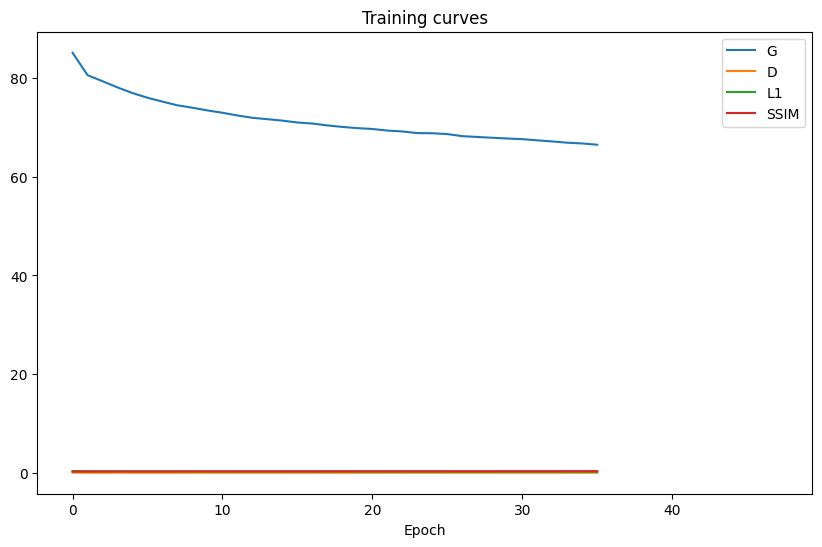

Training complete. Checkpoints in: /kaggle/working/checkpoints
Sample grids in: /kaggle/working/samples


In [13]:
plt.figure(figsize=(10, 6))
for k in history:
    plt.plot(history[k], label=k)
plt.legend()
plt.xlabel("Epoch")
plt.title("Training curves")
plt.savefig(os.path.join(CFG["OUTPUT_DIR"], "training_curves.png"))
plt.show()

with open(os.path.join(CFG["OUTPUT_DIR"], "history.json"), "w") as f:
    json.dump(history, f)

print("Training complete. Checkpoints in:", CKPT_DIR)
print("Sample grids in:", SAMPLE_DIR)

---
# Testing / Evaluation

Everything below loads a saved checkpoint and scores it on the held-out test split (`VAL_RATIO` fraction, same `SPLIT_SEED`) — genuinely unseen during training.

## 13. Load checkpoint for evaluation

Change `EVAL_CHECKPOINT` to a specific epoch file (e.g. `"epoch_060.pt"`) if you don't want the most recent one.

In [14]:
EVAL_CHECKPOINT = "last.pt"

eval_ckpt_path = os.path.join(CKPT_DIR, EVAL_CHECKPOINT)
assert os.path.exists(eval_ckpt_path), f"Checkpoint not found: {eval_ckpt_path}"
eval_ckpt = torch.load(eval_ckpt_path, map_location=DEVICE)
G.load_state_dict(eval_ckpt["G"])
G.eval()
print(f"Loaded generator from {eval_ckpt_path} (epoch {eval_ckpt.get('epoch', '?')})")

Loaded generator from /kaggle/working/checkpoints/last.pt (epoch 59)


### Recovering an older checkpoint (skip this if you trained with this version of the notebook)

If you have a checkpoint trained with an earlier version of this notebook that used `BatchNorm2d` in `AttentionGate`, its BatchNorm running stats may have been silently corrupted with NaN during an early training step — this shows up as NaN PSNR/SSIM and blank generated images at test time, even though training losses looked completely normal. You don't need to retrain: the learned weights are almost always fine, only the running stats need recalculating. Run this cell only if you're hitting that symptom; otherwise skip straight to the metrics cell below.

In [15]:
def reset_batchnorm_stats(model):
    fixed_any = False
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.reset_running_stats()
            fixed_any = True
    return fixed_any

if reset_batchnorm_stats(G):
    print("Found BatchNorm2d layers — recalibrating running stats from training data...")
    print("NaN in weights (should be False):", any(torch.isnan(p).any().item() for p in G.parameters()))
    G.train()
    with torch.no_grad():
        for i, (sar, opt) in enumerate(train_loader):
            sar = sar.to(DEVICE)
            _ = G(sar)
            if i + 1 >= 200:
                break
    G.eval()
    print("Recalibration complete.")
else:
    print("No BatchNorm2d layers found in G (this notebook's InstanceNorm2d version) — nothing to recalibrate.")

No BatchNorm2d layers found in G (this notebook's InstanceNorm2d version) — nothing to recalibrate.


## 14. Metrics — PSNR + SSIM over the full test set

In [16]:
RESULT_DIR = os.path.join(CFG["OUTPUT_DIR"], "test_results")
os.makedirs(RESULT_DIR, exist_ok=True)

def psnr(img1, img2, max_val=1.0):
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return 100.0
    return 20 * np.log10(max_val / np.sqrt(mse))


test_loader = DataLoader(val_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False, num_workers=2)

psnr_scores, ssim_scores = [], []
grids_saved = 0
NUM_SAMPLE_GRIDS = 5

with torch.no_grad():
    for batch_idx, (sar, opt) in enumerate(test_loader):
        sar, opt = sar.to(DEVICE), opt.to(DEVICE)
        fake = G(sar)

        fake01 = ((fake + 1) / 2).clamp(0, 1)
        opt01 = ((opt + 1) / 2).clamp(0, 1)

        for i in range(fake01.size(0)):
            psnr_scores.append(psnr(fake01[i:i + 1], opt01[i:i + 1]))
            ssim_scores.append(ssim(fake01[i:i + 1], opt01[i:i + 1]).item())

        if grids_saved < NUM_SAMPLE_GRIDS:
            sar_rgb = sar.repeat(1, 3, 1, 1)
            grid_tensor = torch.cat([(sar_rgb + 1) / 2, fake01, opt01], dim=0)
            grid = vutils.make_grid(grid_tensor, nrow=sar.size(0))
            vutils.save_image(grid, os.path.join(RESULT_DIR, f"comparison_{batch_idx:03d}.png"))
            grids_saved += 1

mean_psnr, std_psnr = float(np.mean(psnr_scores)), float(np.std(psnr_scores))
mean_ssim, std_ssim = float(np.mean(ssim_scores)), float(np.std(ssim_scores))

print("=" * 50)
print(f"Test set size : {len(val_ds)} images")
print(f"PSNR  : {mean_psnr:.3f} +/- {std_psnr:.3f} dB")
print(f"SSIM  : {mean_ssim:.4f} +/- {std_ssim:.4f}")
print("=" * 50)
print(f"Comparison grids (SAR | Generated | Ground Truth) saved to: {RESULT_DIR}")

with open(os.path.join(RESULT_DIR, "metrics.txt"), "w") as f:
    f.write(f"Test set size: {len(val_ds)}\n")
    f.write(f"PSNR: {mean_psnr:.3f} +/- {std_psnr:.3f} dB\n")
    f.write(f"SSIM: {mean_ssim:.4f} +/- {std_ssim:.4f}\n")

Test set size : 319 images
PSNR  : 17.669 +/- 2.929 dB
SSIM  : 0.3393 +/- 0.1155
Comparison grids (SAR | Generated | Ground Truth) saved to: /kaggle/working/test_results


## 15. Quick visual preview

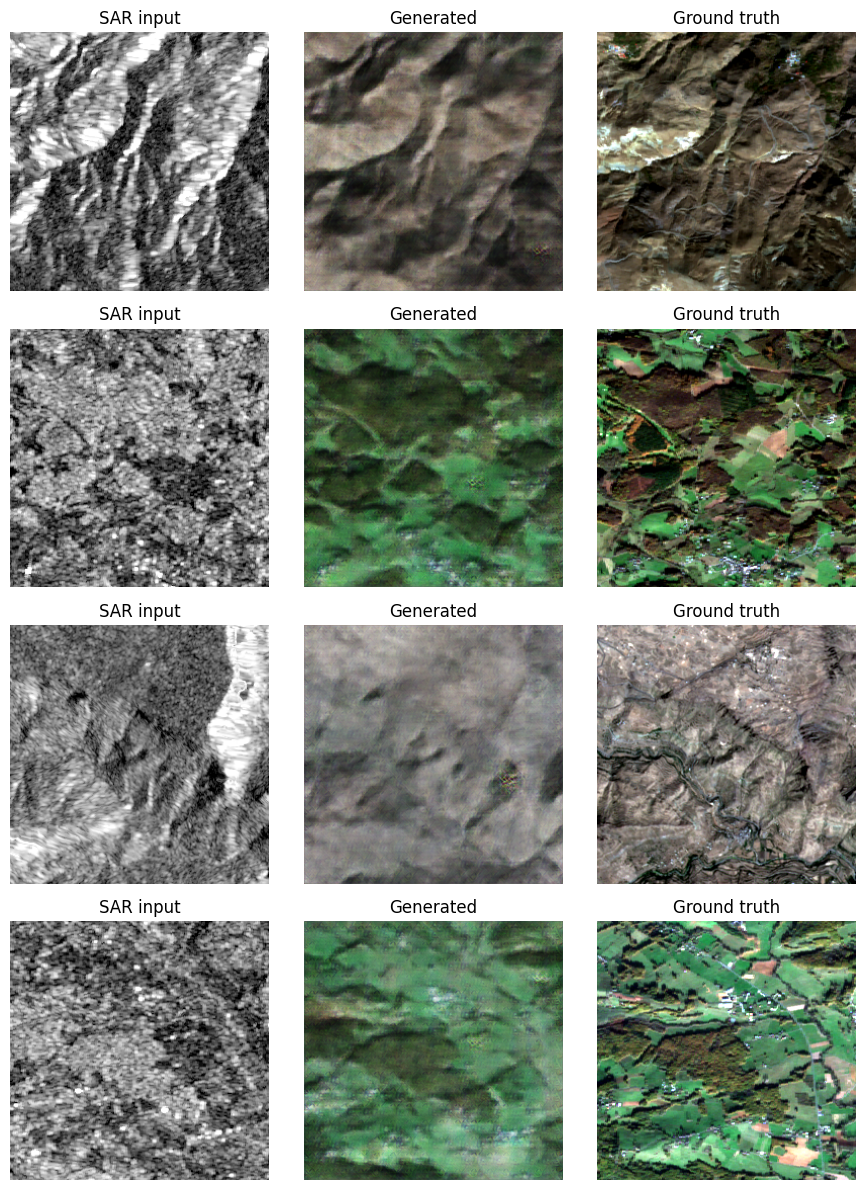

In [17]:
sar, opt = next(iter(test_loader))
sar, opt = sar.to(DEVICE), opt.to(DEVICE)
with torch.no_grad():
    fake = G(sar)

n_show = min(4, sar.size(0))
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(((sar[i, 0].cpu() + 1) / 2), cmap="gray")
    axes[i, 0].set_title("SAR input")
    axes[i, 1].imshow(((fake[i].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1))
    axes[i, 1].set_title("Generated")
    axes[i, 2].imshow(((opt[i].cpu().permute(1, 2, 0) + 1) / 2).clamp(0, 1))
    axes[i, 2].set_title("Ground truth")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "quick_preview.png"))
plt.show()